# Gradient Descent Implementation For Linear Regression

Gradient Descent Types:
- Batch Gradient Descent
- Stochastic Gradient Descent
- Mini Batch Gradient Descent

## 1. Simple Linear Regression Example

### Synthetic Regression Data

In [2]:
from sklearn.datasets import make_regression
import numpy as np

In [3]:
X, y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

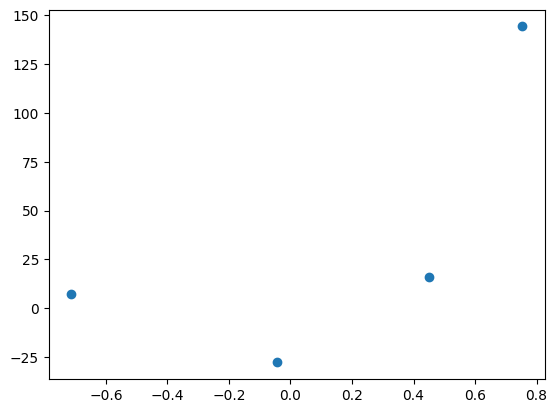

In [4]:
import matplotlib.pyplot as plt
plt.scatter(X, y)

### Sklearn baseline for comparisons

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
reg = LinearRegression()
reg.fit(X, y)

LinearRegression()

In [7]:
reg.coef_

array([78.35063668])

In [8]:
reg.intercept_

np.float64(26.15963284313262)

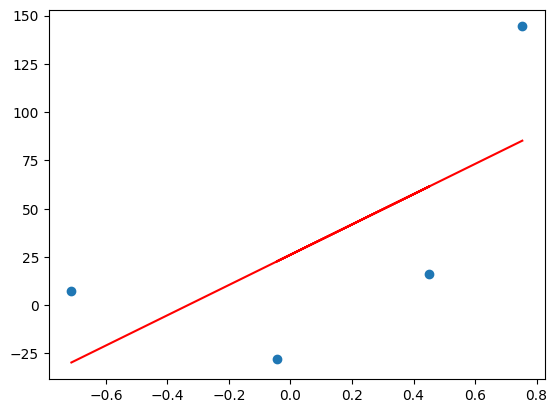

In [9]:
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red')

### Gradient Descent Intuition

- Lets apply Gradient Descent assuming slope is constant m = 78.35
- Lets assume the starting value for intercept b = 0

In [10]:
# Initial State
m = 78.35
b = 0

y_pred = ((m * X) + b).reshape(4)
y_pred

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

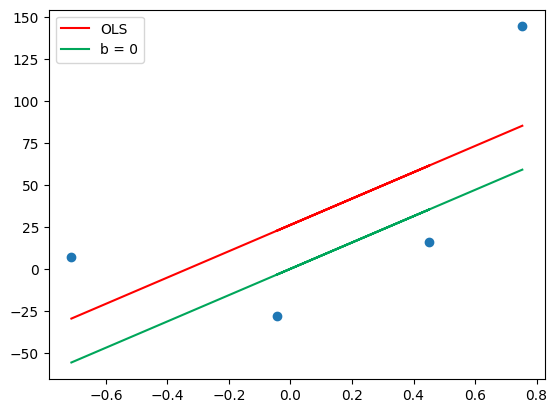

In [11]:
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred, color='#00a65a', label='b = 0')
plt.legend()
plt.show()

In [12]:
# 1st iteration of gradient descent

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-209.27763408209216)

In [13]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope * lr
step_size

np.float64(-20.927763408209216)

In [14]:
# Calculating the new intercept
b = b - step_size
b

np.float64(20.927763408209216)

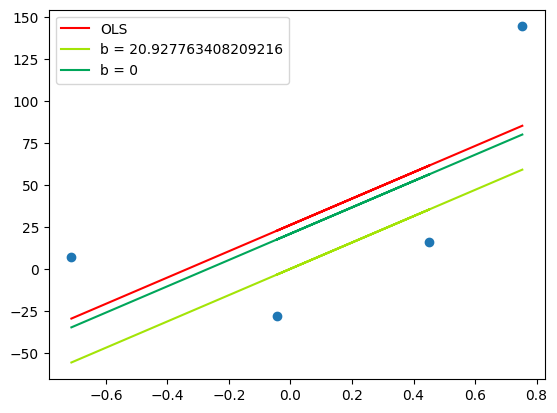

In [15]:
y_pred1 = ((78.35 * X) + b).reshape(4)
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred, color='#a3e407', label='b = {}'.format(b))
plt.plot(X, y_pred1, color='#00a65a', label='b = 0')
plt.legend()
plt.show()

In [16]:
# 2nd iteration

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-41.85552681641843)

In [17]:
step_size = loss_slope * lr
step_size

np.float64(-4.185552681641844)

In [18]:
b = b - step_size
b

np.float64(25.11331608985106)

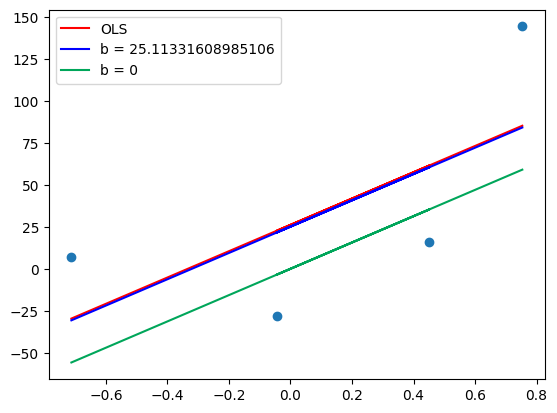

In [19]:
y_pred2 = ((78.35 * X) + b).reshape(4)
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS')
plt.plot(X, y_pred2, color='blue', label='b = {}'.format(b))
plt.plot(X, y_pred, color='#00a65a', label='b = 0')
plt.legend()
plt.show()

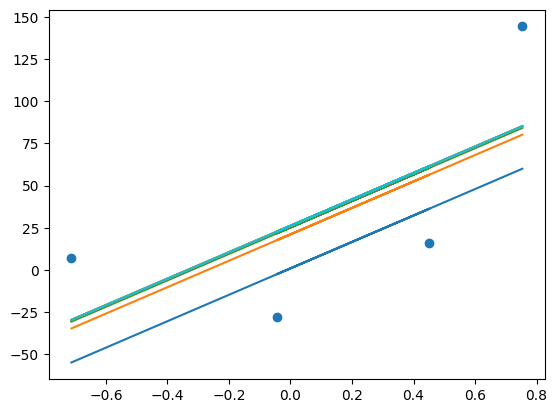

In [20]:
# Looping solution
b = -100
m = 78.35
lr = 0.1

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() - b)
    b = b - (lr * loss_slope)

    y_pred = m * X + b
    plt.plot(X, y_pred)

plt.scatter(X, y)

### Simple Linear Regression With GD - Batch GD

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [22]:
X, y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

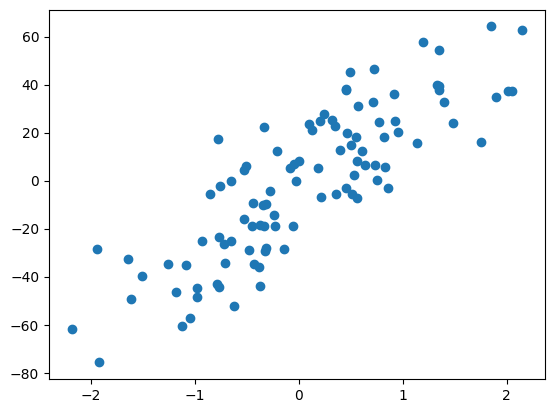

In [24]:
plt.scatter(X, y)

In [25]:
lr = LinearRegression()

In [26]:
lr.fit(X_train, y_train)
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [27]:
np.mean(cross_val_score(lr, X, y, scoring='r2', cv=10))

np.float64(0.6375011587464419)

In [15]:
class GDRegressor:

    def __init__(self, learning_rate, epochs):
        self.m = 100
        self.b = -120
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X, y):
        for i in range(self.epochs):
            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b) * X.ravel())
            self.b = self.b - (self.lr * loss_slope_b)
            self.m = self.m - (self.lr * loss_slope_m)
        
        #     y_pred = self.m * X + self.b
        #     plt.plot(X, y_pred)
        
        # plt.scatter(X, y)
        print(self.m, self.b)

    def predict(self, X):
        return self.m * X + self.b

In [29]:
gd = GDRegressor(0.001, 50)

In [30]:
gd.fit(X_train, y_train)

28.159367347119066 -2.3004574196824854


In [31]:
y_pred = lr.predict(X_test)

In [32]:
r2_score(y_test, y_pred)

0.6345158782661012

## 2. Batch Gradient Descent

Notes:
- For multivariate linear regression prepend a 1 to each row of input data.
- Loss function (MSE): L = 1/n ∑ (yi - y_pred)^2
- Derivative of Loss function wrt any one coefficient: dL/dbm = -2/n ∑ (yi - y_pred) Xim

### Data loading

In [18]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [19]:
X, y = load_diabetes(return_X_y=True)

In [20]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

### Sklearn baseline for comparisons

In [22]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [23]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [24]:
y_pred = reg.predict(X_test)
r2_score(y_test, y_pred)

0.4399338661568968

### From scratch implementation of Batch GD

In [16]:
class GDRegressor:

    def __init__(self, learning_rate=0.01, epochs=100):

        self.coef = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X_train, y_train):
        # init coefficients
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            # update all coefs and the intercept
            y_pred = np.dot(X_train, self.coef_) + self.intercept_
            intercept_der = -2 * np.mean(y_train - y_pred)
            self.intercept_ = self.intercept_ - (self.lr * intercept_der)

            coef_der = -2 * np.dot((y_train - y_pred), X_train) / X_train.shape[0]
            self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_, self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [38]:
gdr = GDRegressor(epochs=1000, learning_rate=0.01)

In [39]:
gdr.fit(X_train, y_train)

150.7529235828462 [ 15.98156223   3.59524752  41.65671073  32.55163341  14.77244856
  11.42882105 -24.66648529  27.6427229   41.18745291  25.180466  ]


In [40]:
y_pred = gdr.predict(X_test)

In [41]:
r2_score(y_test, y_pred)

0.1036656910899234

## 3. Stochastic Gradient Descent

Note:

- In each epoch Stochastic Gradient Descent uses a single row randomly selected to update the coefficients for a total of n times, where n is the no. of tuples in the data.
- Due to the more frequent updates, SGD converges faster and requires comparatively lesser number of epochs than Batch GD.

In [21]:
class SGDRegressor:

    def __init__(self, learning_rate=0.01, epochs=100):

        self.coef = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs

    def fit(self, X_train, y_train):
        # init coefficients
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):
            for j in range(X_train.shape[0]):
                idx = np.random.randint(0, X_train.shape[0])
                y_pred = np.dot(X_train[idx], self.coef_) + self.intercept_
                
                intercept_der = -2 * (y_train[idx] - y_pred)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 * np.dot((y_train[idx] - y_pred), X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_, self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [26]:
sgd = SGDRegressor(learning_rate=0.01, epochs=100)

In [27]:
sgd.fit(X_train, y_train)

152.2426685360925 [  32.04792974 -143.41702127  453.93845913  301.66435409  -21.59638286
  -93.72846898 -189.39172048  111.25054155  415.62777792  118.1512572 ]


In [28]:
y_pred = sgd.predict(X_test)

In [29]:
r2_score(y_test, y_pred)

0.45292676507292895

### Training time comparison between BGD and SGD

In [42]:
import time

start = time.time()
gdr.fit(X_train, y_train)
print("Time taken to train with BGD:", time.time() - start)

start = time.time()
sgd.fit(X_train, y_train)
print("Time taken to train with SGD:", time.time() - start)

150.7529235828462 [ 15.98156223   3.59524752  41.65671073  32.55163341  14.77244856
  11.42882105 -24.66648529  27.6427229   41.18745291  25.180466  ]
Time taken to train with BGD: 0.0283505916595459
151.30904396447028 [  21.59367776 -147.27833099  453.51440267  319.39831703  -29.84668998
  -97.61333887 -189.03817896  109.29503656  405.43800305  110.46645692]
Time taken to train with SGD: 0.4740474224090576


**Note**: Time taken to complete 1 epoch in SGD is greater than BGD

## 4. Mini Batch Gradient Descent

Note:

- In each epoch Mini Batch Gradient Descent uses batches of randomly selected samples to update the coefficients for a total of n times, where n is the (no. of tuples in the data) / (batch size)

In [44]:
import random

class MBGDRegressor:

    def __init__(self, batch_size=32, learning_rate=0.01, epochs=100):

        self.coef = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size

    def fit(self, X_train, y_train):
        # init coefficients
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])

        for i in range(self.epochs):

            for j in range(X_train.shape[0] // self.batch_size):
                idx = random.sample(range(X_train.shape[0]), self.batch_size)
                y_pred = np.dot(X_train[idx], self.coef_) + self.intercept_
                intercept_der = -2 * np.mean(y_train[idx] - y_pred)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)
    
                coef_der = -2 * np.dot((y_train[idx] - y_pred), X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)

        print(self.intercept_, self.coef_)

    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [49]:
mbr = MBGDRegressor(batch_size=X_train.shape[0] // 20, learning_rate=0.01, epochs=50)

In [50]:
mbr.fit(X_train, y_train)

152.86940070163692 [  61.46714454  -57.27747434  346.50986721  238.05747821   13.96308708
  -31.7841718  -179.05372355  129.97989984  323.10858444  128.65247974]


In [51]:
y_pred = mbr.predict(X_test)

In [52]:
r2_score(y_test, y_pred)

0.43178752677002563

## 5. SGDRegressor from Sklearn

### a. Scikit-learn implementation of Stochastic Gradient Descent

In [53]:
from sklearn.linear_model import SGDRegressor

In [54]:
reg = SGDRegressor(max_iter=100, learning_rate='constant', eta0=0.01)

In [55]:
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
r2_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.43053727737962044

### b. Mini Batch Gradient Descent using SGDRegressor

In [62]:
sgd = SGDRegressor(learning_rate='constant', eta0=0.1)

In [63]:
batch_size = 35

for i in range(100):
    idx = random.sample(range(X_train.shape[0]), batch_size)
    sgd.partial_fit(X_train[idx], y_train[idx])

In [64]:
sgd.coef_

array([  56.6437371 ,  -52.15026926,  334.36213513,  250.03610624,
         21.47643865,  -21.68907087, -171.21255783,  134.13086178,
        311.7531672 ,  133.40240375])

In [65]:
sgd.intercept_

array([154.24579146])

In [66]:
y_pred = sgd.predict(X_test)

In [67]:
r2_score(y_test, y_pred)

0.4269592951902835